# **1. Imports and config**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
sns.set_context("talk")

COLORS = {"actual": "#222222", "primary": "#4C72B0", "secondary": "#55A868", "accent": "#C44E52", "soft": "#8172B2", "gray": "#8C8C8C"}


# **2. Data loding and cleaning**

### **2.1 Combining the data**

In [2]:
files = [
    "/content/WT-2020.csv",
    "/content/WT-2021.csv",
    "/content/WT-2022.csv",
    "/content/WT-2023.csv",
    "/content/WT-2024.csv",
    "/content/WT-2025.csv"
]

raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


### **2.2 Validating the data**

In [3]:
raw["sample.sampleDateTime"] = pd.to_datetime(
    raw["sample.sampleDateTime"], errors="coerce"
)

raw["result"] = pd.to_numeric(raw["result"], errors="coerce")

raw = raw.dropna(subset=["sample.sampleDateTime", "result"])
raw = raw[raw["result"] >= 0]


### **2.3 Handling the censored measurements**

In [4]:
raw["is_censored"] = raw["resultQualifier.notation"].isin(["<", ">"])

# conservative handling
raw.loc[raw["is_censored"], "result"] *= 0.5


# **3. Exploratory Data Analysis**

### **3.1 Sampling density over time**

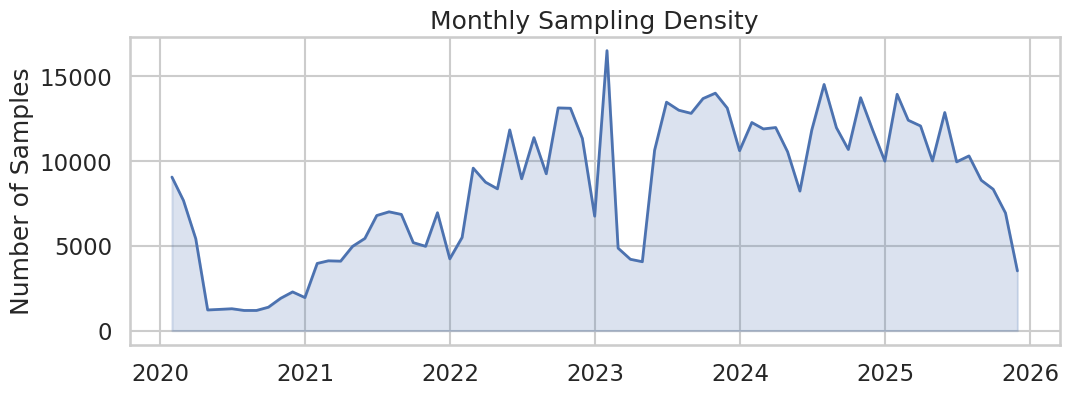

In [5]:
sampling = (
    raw
    .set_index("sample.sampleDateTime")
    .resample("M")
    .size()
)

plt.figure(figsize=(12,4))
plt.plot(sampling, color=COLORS["primary"], linewidth=2)
plt.fill_between(sampling.index, sampling.values,
                 color=COLORS["primary"], alpha=0.2)
plt.title("Monthly Sampling Density")
plt.ylabel("Number of Samples")
plt.show()

### **3.2 Determinant coverage**

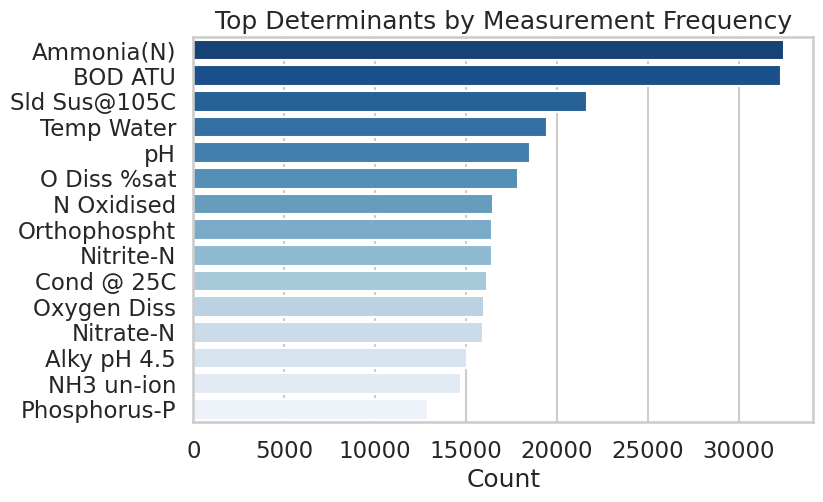

In [6]:
top_dets = raw["determinand.label"].value_counts().head(15)

plt.figure(figsize=(8,5))
sns.barplot(
    x=top_dets.values,
    y=top_dets.index,
    palette="Blues_r"
)
plt.title("Top Determinants by Measurement Frequency")
plt.xlabel("Count")
plt.ylabel("")
plt.show()


### **3.3 Spatial distribution of sampling locations**

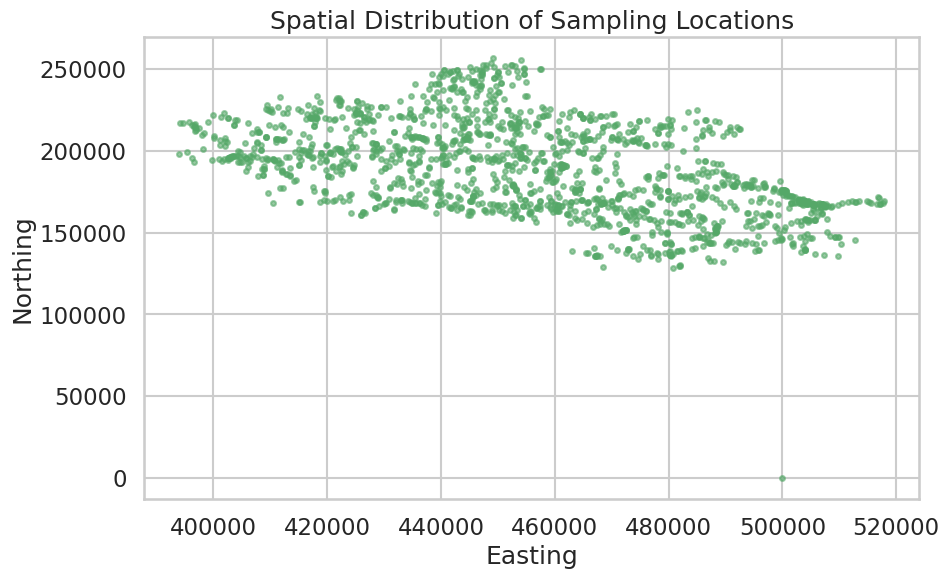

In [7]:
coords = (
    raw[
        ["sample.samplingPoint.easting",
         "sample.samplingPoint.northing"]
    ]
    .dropna()
    .drop_duplicates()
)

plt.figure(figsize=(10,6))
plt.scatter(
    coords.iloc[:,0],
    coords.iloc[:,1],
    s=12,
    alpha=0.6,
    color=COLORS["secondary"]
)
plt.title("Spatial Distribution of Sampling Locations")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.show()


# **4. Feature Engineering**

### **4.1 Selecting pollution relevant determinants**

In [8]:
pollution_dets = [
    "Ammonia(N)", "Ammonia",
    "Nitrate-N", "Nitrate",
    "Phosphate", "Orthophosphate",
    "Dissolved oxygen", "O Diss %sat",
    "pH"
]

df = raw[raw["determinand.label"].isin(pollution_dets)]


### **4.2 Monthly aggregation**

In [9]:
monthly = (
    df
    .set_index("sample.sampleDateTime")
    .groupby([
        pd.Grouper(freq="M"),
        "sample.samplingPoint.notation",
        "determinand.label"
    ])["result"]
    .mean()
    .reset_index()
)


### **4.3 Pivot and canonical determinant mapping**

In [10]:
pivot = monthly.pivot_table(
    index=["sample.sampleDateTime",
           "sample.samplingPoint.notation"],
    columns="determinand.label",
    values="result"
).sort_index()

CANONICAL = {
    "Ammonia": ["Ammonia(N)", "Ammonia"],
    "Nitrate": ["Nitrate", "Nitrate-N"],
    "Phosphate": ["Phosphate", "Orthophosphate"],
    "Dissolved_oxygen": ["Dissolved oxygen", "O Diss %sat"],
    "pH": ["pH"]
}

rename = {}
for k, vs in CANONICAL.items():
    for v in vs:
        if v in pivot.columns:
            rename[v] = k

pivot = pivot.rename(columns=rename)
pivot = pivot[list(rename.values())]


# **5. Pollution Pressure Index (PPI)**

### **5.1 Regulatory normalized PPI**

In [11]:
THRESHOLDS = {
    "Ammonia": 0.3,
    "Nitrate": 50,
    "Phosphate": 0.1,
    "Dissolved_oxygen": 5,
    "pH": 8.5
}

def compute_ppi(row):
    return sum(
        row[k] / v for k, v in THRESHOLDS.items()
        if pd.notna(row[k])
    )

pivot["PPI"] = pivot.apply(compute_ppi, axis=1)


### **5.2 Visualizing PPI**

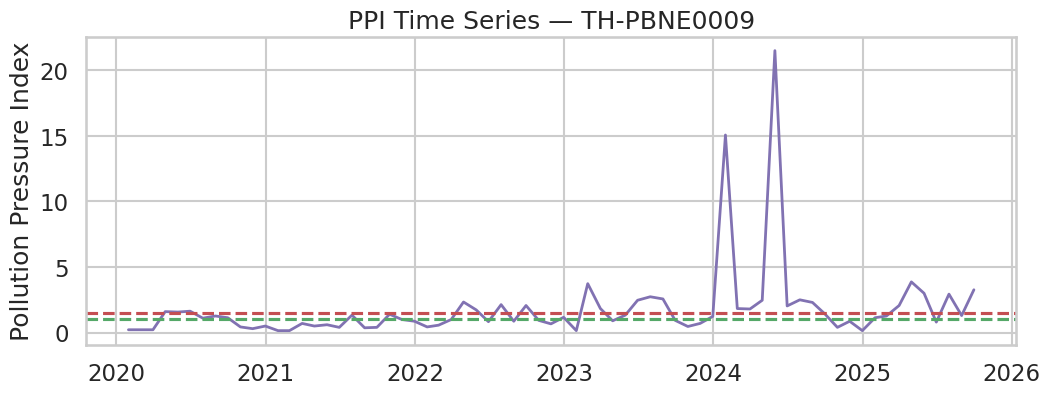

In [12]:
location = pivot.index.get_level_values(1)[0]
series = pivot.xs(location, level=1)["PPI"].dropna()

plt.figure(figsize=(12,4))
plt.plot(series, color=COLORS["soft"], linewidth=2)
plt.axhline(1.0, linestyle="--", color=COLORS["secondary"])
plt.axhline(1.5, linestyle="--", color=COLORS["accent"])
plt.title(f"PPI Time Series — {location}")
plt.ylabel("Pollution Pressure Index")
plt.show()


# **6. Time series diagnostics**

In [13]:
adf_stat, pval, *_ = adfuller(series.dropna())

pd.DataFrame({
    "ADF Statistic": [adf_stat],
    "p-value": [pval]
})


,ADF Statistic,p-value
0,-2.392685,0.143812


# **7. Forecasting models**

### **7.1 Train/Test Split and Scaling**

In [14]:
scaler = StandardScaler()
series_scaled = pd.Series(
    scaler.fit_transform(series.values.reshape(-1,1)).flatten(),
    index=series.index
)

split = int(len(series_scaled) * 0.8)
train, test = series_scaled[:split], series_scaled[split:]


### **7.2 SARIMA model**

In [15]:
sarima = SARIMAX(
    train,
    order=(1,1,0),
    enforce_stationarity=True,
    enforce_invertibility=True
)

sarima_fit = sarima.fit(disp=False)

sarima_forecast_scaled = sarima_fit.forecast(len(test))
sarima_pred = scaler.inverse_transform(
    sarima_forecast_scaled.values.reshape(-1,1)
).flatten()

y_true = scaler.inverse_transform(
    test.values.reshape(-1,1)
).flatten()


### **7.3 LSTM model**

In [16]:
mm = MinMaxScaler()
scaled = mm.fit_transform(series.values.reshape(-1,1))

WINDOW = 12

def make_seq(data, w):
    X, y = [], []
    for i in range(w, len(data)):
        X.append(data[i-w:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X, y = make_seq(scaled, WINDOW)

split_seq = split - WINDOW
X_train, X_test = X[:split_seq], X[split_seq:]
y_train, y_test = y[:split_seq], y[split_seq:]


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm = Sequential([
    LSTM(32, input_shape=(WINDOW, 1)),
    Dense(1)
])

lstm.compile(optimizer="adam", loss="mse")
lstm.fit(X_train, y_train, epochs=25,
          batch_size=8, verbose=0)

lstm_pred = mm.inverse_transform(
    lstm.predict(X_test)
).flatten()

lstm_pred = lstm_pred[:len(y_true)]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


# **8. Model Evaluation and Comparison**

### **8.1 Metrics table**

In [18]:
results = pd.DataFrame({
    "Model": ["SARIMA", "LSTM"],
    "MAE": [
        mean_absolute_error(y_true, sarima_pred),
        mean_absolute_error(y_true, lstm_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_true, sarima_pred)),
        np.sqrt(mean_squared_error(y_true, lstm_pred))
    ]
})

results


,Model,MAE,RMSE
0,SARIMA,1.103044,1.248609
1,LSTM,2.621281,3.222087


### **8.2 Forecast Comparison plot**

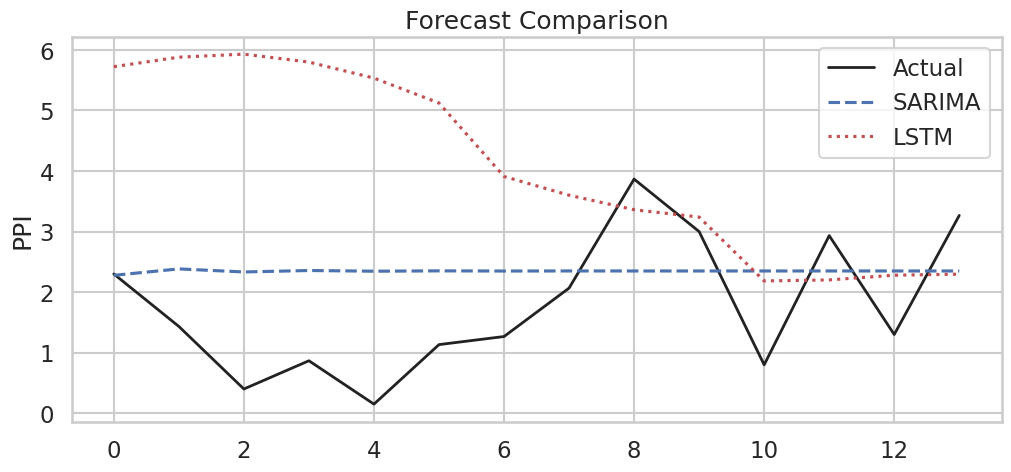

In [19]:
plt.figure(figsize=(12,5))
plt.plot(y_true, label="Actual",
         color=COLORS["actual"], linewidth=2)
plt.plot(sarima_pred, label="SARIMA",
         color=COLORS["primary"], linestyle="--")
plt.plot(lstm_pred, label="LSTM",
         color=COLORS["accent"], linestyle=":")

plt.title("Forecast Comparison")
plt.ylabel("PPI")
plt.legend()
plt.show()


### **8.3 Residual Diagnostics**

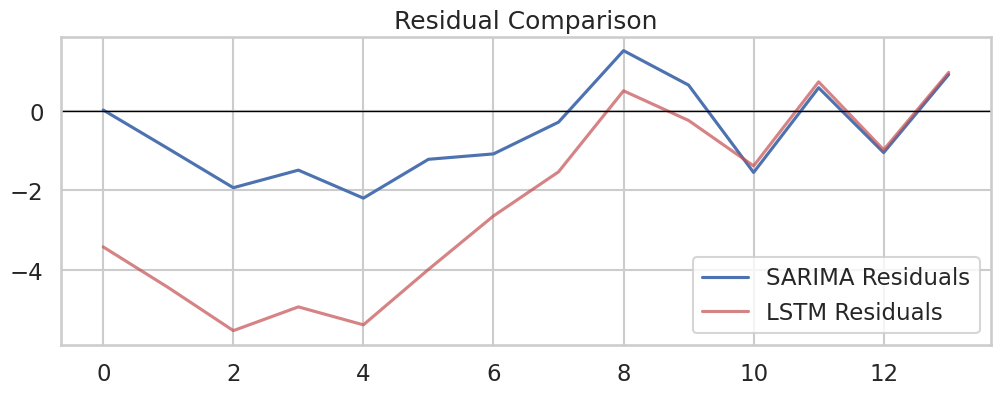

In [20]:
plt.figure(figsize=(12,4))
plt.plot(y_true - sarima_pred,
         label="SARIMA Residuals",
         color=COLORS["primary"])
plt.plot(y_true - lstm_pred,
         label="LSTM Residuals",
         color=COLORS["accent"], alpha=0.7)

plt.axhline(0, color="black", linewidth=1)
plt.legend()
plt.title("Residual Comparison")
plt.show()


# **9. Pollution aware Decision System**

### **9.1 Risk Component functions**

In [21]:
def risk_level_from_ppi(ppi):
    if ppi < 1.0:
        return "Low", "#55A868"
    elif ppi < 1.5:
        return "Moderate", "#F1C40F"
    elif ppi < 2.0:
        return "High", "#E67E22"
    else:
        return "Severe", "#C44E52"


In [22]:
def trend_direction(series, window=6):
    y = series[-window:]
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]

    if slope > 0.05:
        return "Increasing", slope
    elif slope < -0.05:
        return "Decreasing", slope
    else:
        return "Stable", slope


In [23]:
def stability_level(series, window=6):
    vol = series[-window:].std()

    if vol < 0.3:
        return "Stable", vol
    elif vol < 0.7:
        return "Moderately Volatile", vol
    else:
        return "Highly Volatile", vol


### **9.2 Decision Logic**

In [24]:
def final_decision(current_ppi, forecast_ppi, trend, stability):
    """
    Rule-based, explainable logic
    """

    if forecast_ppi >= 2.0:
        return "Severe Pollution Risk"
    if forecast_ppi >= 1.5 and trend == "Increasing":
        return "High Pollution Risk"
    if forecast_ppi >= 1.0 and trend == "Increasing":
        return "Emerging Risk"
    if trend == "Decreasing":
        return "Improving Conditions"
    if stability == "Highly Volatile":
        return "Uncertain / Monitor Closely"

    return "Stable / Acceptable"


### **9.3 Timeline Visualization**

In [25]:
def plot_ppi_context(series, sarima_pred):
    plt.figure(figsize=(12,4))

    plt.plot(series.index, series,
             label="Historical PPI", linewidth=2)

    future_index = pd.date_range(
        start=series.index[-1],
        periods=len(sarima_pred)+1,
        freq="M"
    )[1:]

    plt.plot(future_index, sarima_pred, label="SARIMA Forecast", color=COLORS["accent"], linewidth=2)

    #plt.plot(future_index, sarima_pred, label="SARIMA Forecast", color=COLORS["accent"], linestyle=":")

    plt.axhline(1.0, color="#55A868", linestyle="--", alpha=0.7)
    plt.axhline(1.5, color="#E67E22", linestyle="--", alpha=0.7)
    plt.axhline(2.0, color="#C44E52", linestyle="--", alpha=0.7)

    plt.title("Pollution Pressure Index — Historical & Forecast")
    plt.ylabel("PPI")
    plt.xlabel("Year")
    plt.legend()
    plt.show()


### **9.4 Risk Gauge**

In [26]:
def plot_risk_gauge(ppi, title="Current Pollution Level"):
    level, color = risk_level_from_ppi(ppi)

    plt.figure(figsize=(6,1.8))
    plt.barh([0], [ppi], color=color)
    plt.xlim(0, 3)
    plt.yticks([])
    plt.xlabel("Pollution Pressure Index")
    plt.title(f"{title}: {level}")
    plt.show()


### **9.5 Integrated Decision Function**

In [27]:
def pollution_decision_dashboard(series, sarima_pred, sarima_mae):
    current_ppi = series.iloc[-1]
    forecast_ppi = sarima_pred[-1]

    level, level_color = risk_level_from_ppi(current_ppi)
    trend, slope = trend_direction(series)
    stability, vol = stability_level(series)

    decision = final_decision(
        current_ppi=current_ppi,
        forecast_ppi=forecast_ppi,
        trend=trend,
        stability=stability
    )

    plot_ppi_context(series, sarima_pred)
    plot_risk_gauge(current_ppi, "Current Pollution")
    plot_risk_gauge(forecast_ppi, "Forecasted Pollution")

    summary = pd.DataFrame({
        "Metric": [
            "Current PPI",
            "Forecasted PPI",
            "Current Risk Level",
            "Trend Direction",
            "Stability",
            "Model MAE",
            "Final Assessment"
        ],
        "Value": [
            round(current_ppi, 2),
            round(forecast_ppi, 2),
            level,
            f"{trend} (slope={slope:.3f})",
            f"{stability} (σ={vol:.2f})",
            round(sarima_mae, 2),
            decision
        ]
    })

    return summary


### **9.6 Running the system**

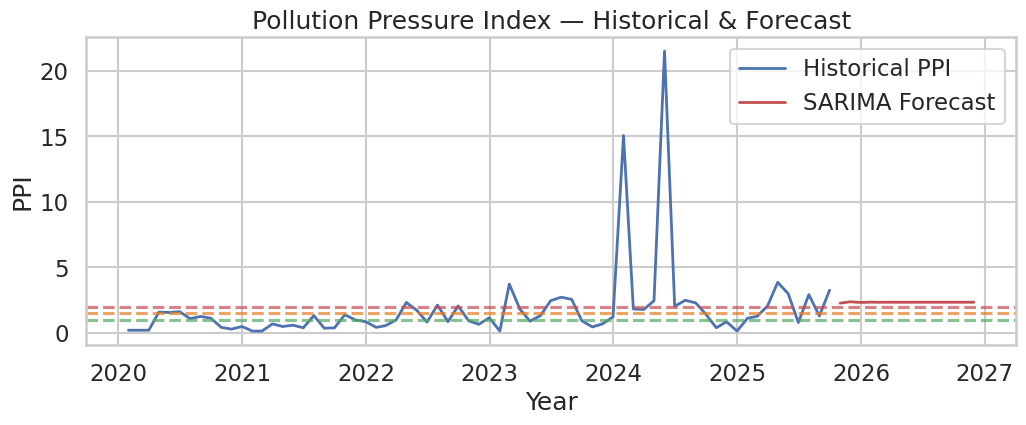

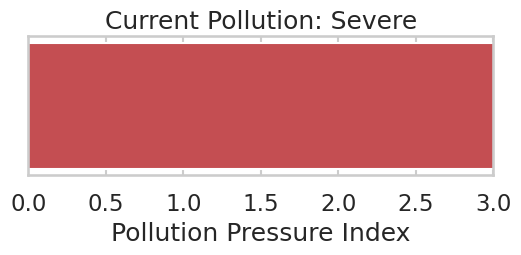

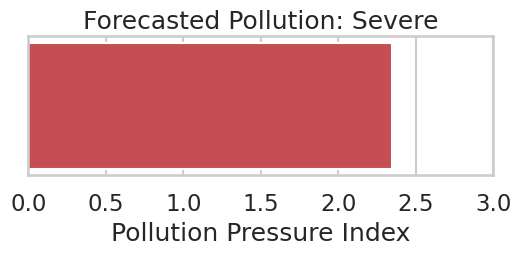

,Metric,Value
0,Current PPI,3.27
1,Forecasted PPI,2.35
2,Current Risk Level,Severe
3,Trend Direction,Decreasing (slope=-0.170)
4,Stability,Highly Volatile (σ=1.20)
5,Model MAE,1.1
6,Final Assessment,Severe Pollution Risk


In [28]:
pollution_decision_dashboard(
    series=series,
    sarima_pred=sarima_pred,
    sarima_mae=results.loc[0, "MAE"]
)
